# Xgboost FIRST TEST

In [2]:
import os
import pandas as pd
folder_path=r'C:\Users\tempe\Desktop\Real World Data'
file_path=r'bank-additional-full.csv'
full_path=os.path.join(folder_path,file_path)
df=pd.read_csv(full_path,sep=';')
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [3]:
cols_to_drop = ['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
print(df.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [4]:
df=df.drop(columns=cols_to_drop).rename(columns={'job': 'job_type', 'default': 'default_status', 
                                                   'housing': 'housing_loan_status', 'loan': 'personal_loan_status', 
                                                   'contact': 'contact_type', 'month': 'contact_month', 
                                                   'day_of_week': 'contact_day_of_week', 'campaign': 'num_contacts', 
                                                   'pdays': 'days_last_contact', 'previous': 'previous_contacts', 
                                                   'poutcome': 'previous_outcome', 
                                                   'y': 'result'})


In [4]:
print(df.head())

   age   job_type  marital    education default_status housing_loan_status  \
0   56  housemaid  married     basic.4y             no                  no   
1   57   services  married  high.school        unknown                  no   
2   37   services  married  high.school             no                 yes   
3   40     admin.  married     basic.6y             no                  no   
4   56   services  married  high.school             no                  no   

  personal_loan_status contact_type contact_month contact_day_of_week  \
0                   no    telephone           may                 mon   
1                   no    telephone           may                 mon   
2                   no    telephone           may                 mon   
3                   no    telephone           may                 mon   
4                  yes    telephone           may                 mon   

   num_contacts  days_last_contact  previous_contacts previous_outcome result  
0           

In [5]:
df['result'] = df['result'].replace({'yes': 1, 'no': 0})
print(df.head())

   age   job_type  marital    education default_status housing_loan_status  \
0   56  housemaid  married     basic.4y             no                  no   
1   57   services  married  high.school        unknown                  no   
2   37   services  married  high.school             no                 yes   
3   40     admin.  married     basic.6y             no                  no   
4   56   services  married  high.school             no                  no   

  personal_loan_status contact_type contact_month contact_day_of_week  \
0                   no    telephone           may                 mon   
1                   no    telephone           may                 mon   
2                   no    telephone           may                 mon   
3                   no    telephone           may                 mon   
4                  yes    telephone           may                 mon   

   num_contacts  days_last_contact  previous_contacts previous_outcome  result  
0          

C:\Users\tempe\AppData\Local\Temp\ipykernel_10796\4212704853.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['result'] = df['result'].replace({'yes': 1, 'no': 0})


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   41188 non-null  int64 
 1   job_type              41188 non-null  object
 2   marital               41188 non-null  object
 3   education             41188 non-null  object
 4   default_status        41188 non-null  object
 5   housing_loan_status   41188 non-null  object
 6   personal_loan_status  41188 non-null  object
 7   contact_type          41188 non-null  object
 8   contact_month         41188 non-null  object
 9   contact_day_of_week   41188 non-null  object
 10  num_contacts          41188 non-null  int64 
 11  days_last_contact     41188 non-null  int64 
 12  previous_contacts     41188 non-null  int64 
 13  previous_outcome      41188 non-null  object
 14  result                41188 non-null  int64 
dtypes: int64(5), object(10)
memory usage

In [7]:
df['result'].value_counts()

result
0    36548
1     4640
Name: count, dtype: int64

In [8]:
df['result'].value_counts(normalize=True)

result
0    0.887346
1    0.112654
Name: proportion, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X = df.drop(columns='result')  # Everything EXCEPT result
y = df['result']               # ONLY result

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=8)

In [12]:
from sklearn.pipeline import Pipeline

In [13]:
from category_encoders.target_encoder import TargetEncoder

In [15]:
from xgboost import XGBClassifier

In [17]:
estimators = [
    ('encoder', TargetEncoder()),
    ('clf', XGBClassifier(random_state=8)) # can customize objective function with the objective parameter
]

In [19]:
pipe = Pipeline(steps=estimators)

In [20]:
pipe

,steps,"[('encoder', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [23]:
from skopt import BayesSearchCV

In [25]:
from skopt.space import Real, Categorical, Integer

In [29]:
search_space = {
    'clf__max_depth': Integer(2,8),
    'clf__learning_rate': Real(0.001, 1.0, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__colsample_bylevel': Real(0.5, 1.0),
    'clf__colsample_bynode' : Real(0.5, 1.0),
    'clf__reg_alpha': Real(0.0, 10.0),
    'clf__reg_lambda': Real(0.0, 10.0),
    'clf__gamma': Real(0.0, 10.0)
}

In [31]:
opt = BayesSearchCV(pipe, search_space, cv=3, n_iter=10, scoring='roc_auc', random_state=8)

In [33]:
opt.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'clf__colsample_bylevel': Real(low=0.5,...m='normalize'), 'clf__colsample_bynode': Real(low=0.5,...m='normalize'), 'clf__colsample_bytree': Real(low=0.5,...m='normalize'), 'clf__gamma': Real(low=0.0,...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'roc_auc'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [35]:
opt.best_estimator_

,steps,"[('encoder', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['job_type', 'marital', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [37]:
opt.best_score_

np.float64(0.7650857193471304)

In [39]:
opt.score(X_test, y_test)

0.7850644487947545

In [41]:
opt.predict(X_test)

array([0, 0, 0, ..., 1, 0, 0], shape=(8238,))

In [43]:
opt.predict_proba(X_test)

array([[0.95746535, 0.04253464],
       [0.96285725, 0.03714276],
       [0.9510564 , 0.04894357],
       ...,
       [0.49343342, 0.5065666 ],
       [0.95782775, 0.04217223],
       [0.84389204, 0.15610796]], shape=(8238, 2), dtype=float32)

In [45]:
opt.best_estimator_.steps

[('encoder',
  TargetEncoder(cols=['job_type', 'marital', 'education', 'default_status',
                      'housing_loan_status', 'personal_loan_status',
                      'contact_type', 'contact_month', 'contact_day_of_week',
                      'previous_outcome'])),
 ('clf',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=0.9425384185492701,
                colsample_bynode=0.9095956806239844,
                colsample_bytree=0.706128679361455, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=1.6598135411398998, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.7929828265552742,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=7, max_leaves=None,
                min_ch

In [47]:
from xgboost import plot_importance

In [48]:
xgboost_step = opt.best_estimator_.steps[1]

In [49]:
xgboost_model = xgboost_step[1]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

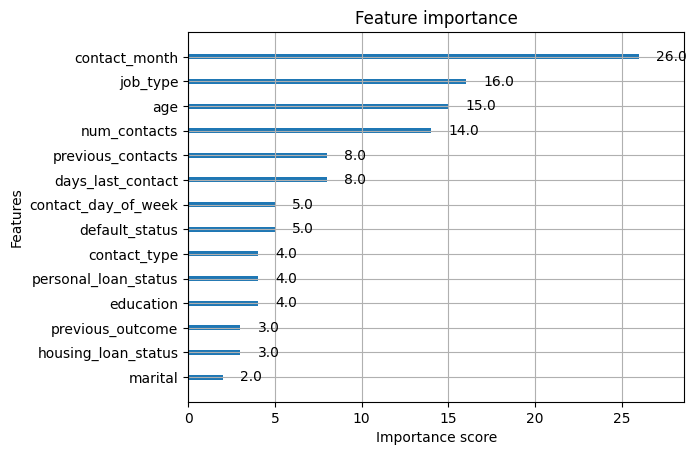

In [50]:
plot_importance(xgboost_model)